In [ ]:
from pathlib import Path
import librosa
import IPython.display as ipd
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd

# Dataset

Can be donwloaded from http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz
and should then be placed in the same folder, as this notebook.

In [ ]:
DATASET_PATH = Path("speech_commands_v0.01/")
assert DATASET_PATH.exists()

OUTPUT_PATH = Path("preprocessed_dataset/")
OUTPUT_PATH.mkdir(exist_ok=True)

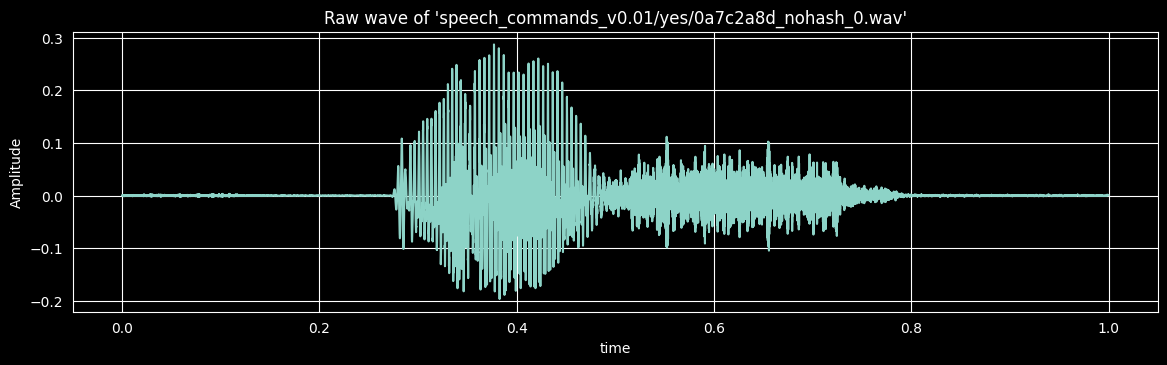

sample_rate=16000


In [13]:
audio_track_path = DATASET_PATH / "yes" / "0a7c2a8d_nohash_0.wav"
samples, sample_rate = librosa.load(audio_track_path, sr=None)
fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(211)
ax1.set_title(f"Raw wave of '{audio_track_path}'")
ax1.set_xlabel('time')
ax1.set_ylabel('Amplitude')
ax1.plot(np.linspace(0, sample_rate/len(samples), sample_rate), samples)
plt.show()

print(f"{sample_rate=}")

In [15]:
samples.min(), samples.max()

(-0.19668579, 0.28720093)

In [ ]:
# Doesn't show anything in PyCharm, but one can open the notebook in Browser using triple-dot in the top-right corner
ipd.display(ipd.Audio(samples, rate=sample_rate))

In [ ]:
samples = librosa.resample(np.asarray(samples, dtype=np.float32), orig_sr=sample_rate,target_sr=8000)
ipd.Audio(samples, rate=8000)

In [ ]:
LABELS = np.array([
    "dog",
    "cat",
    "bird",
    "stop",
    "wow",
    "up",
    "down",
    "go",
    "happy",
    "zero",
])
len(np.unique(LABELS))

In [ ]:
def process_file(file: Path) -> None:
    # Reading with smaller sr automatically resamples
    samples, sample_rate = librosa.load(audio_track_path, sr=8_000)
    assert samples.shape[0] == 8_000, f"sample {file} is NOT 1 second long. {samples.shape=}"

    label = file.parents[0].name
    output_file_path = OUTPUT_PATH / label / file.name
    sf.write(output_file_path, samples, sample_rate)

In [ ]:
y_counts = np.zeros_like(LABELS, dtype=int)

for i, label in tqdm(enumerate(LABELS)):
    output_folder = OUTPUT_PATH / label
    output_folder.mkdir(parents=True, exist_ok=True)

    file_idx = 0
    folder_path = DATASET_PATH / label
    for file_idx, file in enumerate(folder_path.iterdir()):
        process_file(file)

    y_counts[i] = file_idx + 1  # The last index + 1 = size of folder

In [ ]:
plt.bar(LABELS, y_counts)

In [ ]:
df = pd.DataFrame(np.concatenate((LABELS.reshape(-1, 1), y_counts.reshape(-1, 1)), axis=1), columns=["label", "num_samples"])
df.to_csv("preprocessed_dataset/labels_num_samples.csv", index=False)
df